In [1]:
import pandas as pd
import ast
import re

log_file_path = '.log'
data_entries = []
with open(log_file_path, 'r') as file:
    for line in file:
        # Search for lines that contain the dictionary data
        match = re.search(r"State :(\{.*\})", line)
        if match:
            # Extract the dictionary part
            state_data_str = match.group(1)

            # Convert the string representation of the dictionary to a Python dictionary
            state_data = ast.literal_eval(state_data_str)

            # Append the parsed data to the list
            data_entries.append(state_data)

sub_state_series_df = pd.json_normalize(data_entries, sep='.')
sub_state_series_df['timestamp'] = pd.to_datetime(sub_state_series_df['timestamp'], unit='s')
sub_state_series_df.set_index('timestamp', inplace=True)
sub_state_series_df['reward'] = (
        sub_state_series_df['grid_sim.feed_to_grid'] * 0.1
        - sub_state_series_df['grid_sim.taken_from_grid'] * 0.4
)
# sub_state_series_df.to_csv(
#     # 'sub_state_series_df.000.csv'
#     'sub_state_series_df.004.csv'
# )

/tmp/ipykernel_231434/2258959109.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['batt_sim.stored'] =df_plot['batt_sim.stored'] / 10


<Axes: xlabel='timestamp'>

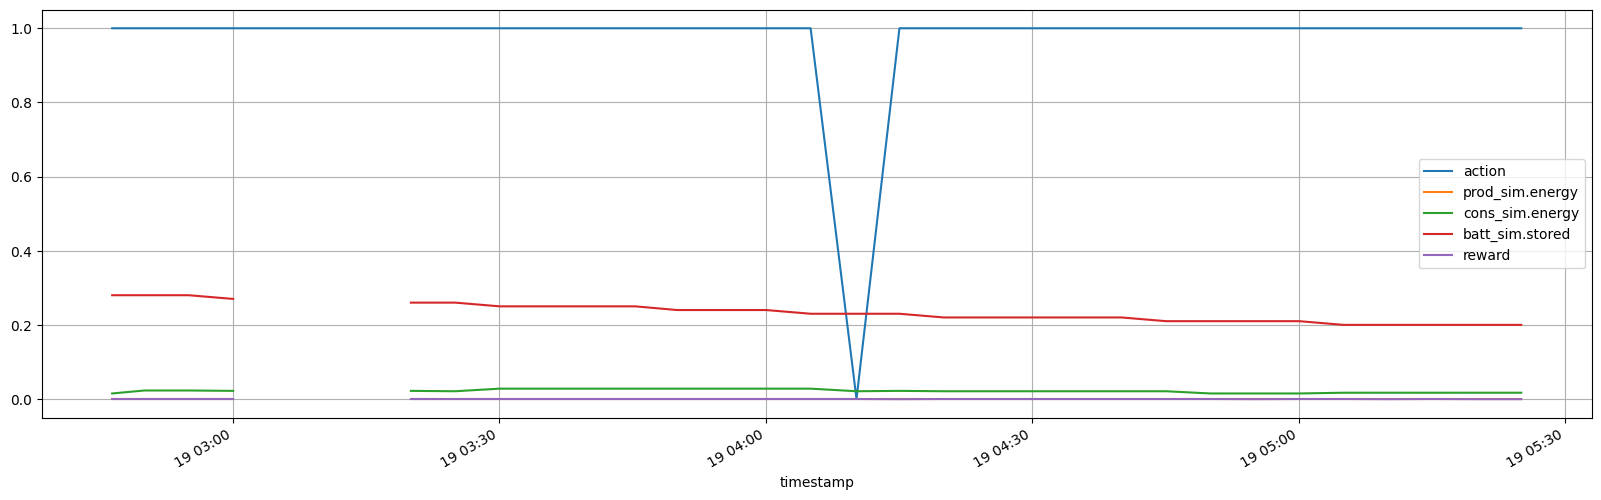

In [3]:
df_plot = sub_state_series_df[[
    'action',
    'prod_sim.energy',
    'cons_sim.energy',
    'batt_sim.stored',
    'reward',
]]
df_plot['batt_sim.stored'] = df_plot['batt_sim.stored'] / 10
df_plot.plot(figsize=(20, 6), grid=True)